# CGI Data Exploration

3-9-26

## Some Questions to Explore:
- What proportion of CGIs are bound by 777?
- What proportion of 777-bound sites are at CGIs?
- What size (genomic span) are 777-bound sites?
- When normalized and not, where are 777-bound sites binding at CGIs?

In [1]:
# Find all CGIs

In [2]:
cd /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration

In [3]:
module load bedtools

[+] Loading bedtools  2.31.1 


In [4]:
bedtools intersect


Tool:    bedtools intersect (aka intersectBed)
Version: v2.31.1
Summary: Report overlaps between two feature files.

Usage:   bedtools intersect [OPTIONS] -a <bed/gff/vcf/bam> -b <bed/gff/vcf/bam>

	Note: -b may be followed with multiple databases and/or 
	wildcard (*) character(s). 
Options: 
	-wa	Write the original entry in A for each overlap.

	-wb	Write the original entry in B for each overlap.
		- Useful for knowing _what_ A overlaps. Restricted by -f and -r.

	-loj	Perform a "left outer join". That is, for each feature in A
		report each overlap with B.  If no overlaps are found, 
		report a NULL feature for B.

	-wo	Write the original A and B entries plus the number of base
		pairs of overlap between the two features.
		- Overlaps restricted by -f and -r.
		  Only A features with overlap are reported.

	-wao	Write the original A and B entries plus the number of base
		pairs of overlap between the two features.
		- Overlapping features restricted by -f and -r.
		  However, A fea

: 1

In [6]:
bedtools intersect -a mm10_CpGislands.bed -b shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -wao > mESC_777_peaks_at_CGIs_numMatch.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369



In [7]:
bedtools intersect -a mm10_CpGislands.bed -b shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed > mESC_777_peaks_at_CGIs.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369



In [8]:
wc -l mESC_777_peaks_at_CGIs_numMatch.bed

17068 mESC_777_peaks_at_CGIs_numMatch.bed


In [9]:
wc -l mESC_777_peaks_at_CGIs.bed

2570 mESC_777_peaks_at_CGIs.bed


In [10]:
wc -l mm10_CpGislands.bed

17017 mm10_CpGislands.bed


In [ ]:
# Get 777 peaks with no CGI

In [11]:
bedtools intersect -a shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -b mm10_CpGislands.bed -v  > mESC_777_peaks_NOT_at_CGIs.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071



In [16]:
bedtools intersect -a shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -b mESC_777_peaks_at_CGIs.bed -v  > mESC_777_peaks_NOT_at_CGIs_intersectWithCGIpeaks.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071



In [17]:
wc -l mESC_777_peaks_NOT_at_CGIs_intersectWithCGIpeaks.bed

623 mESC_777_peaks_NOT_at_CGIs_intersectWithCGIpeaks.bed


In [12]:
wc -l mESC_777_peaks_NOT_at_CGIs.bed

623 mESC_777_peaks_NOT_at_CGIs.bed


In [14]:
bedtools intersect -a mESC_777_peaks_at_CGIs.bed -b mESC_777_peaks_NOT_at_CGIs.bed > intersectTestShouldBeZero.bed

***** WARNING: File mESC_777_peaks_NOT_at_CGIs.bed has inconsistent naming convention for record:
chr1	22327660	22327974

***** WARNING: File mESC_777_peaks_NOT_at_CGIs.bed has inconsistent naming convention for record:
chr1	22327660	22327974



In [15]:
wc -l intersectTestShouldBeZero.bed

0 intersectTestShouldBeZero.bed


In [18]:
wc -l shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed

3163 shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed


### Get this view in IGV
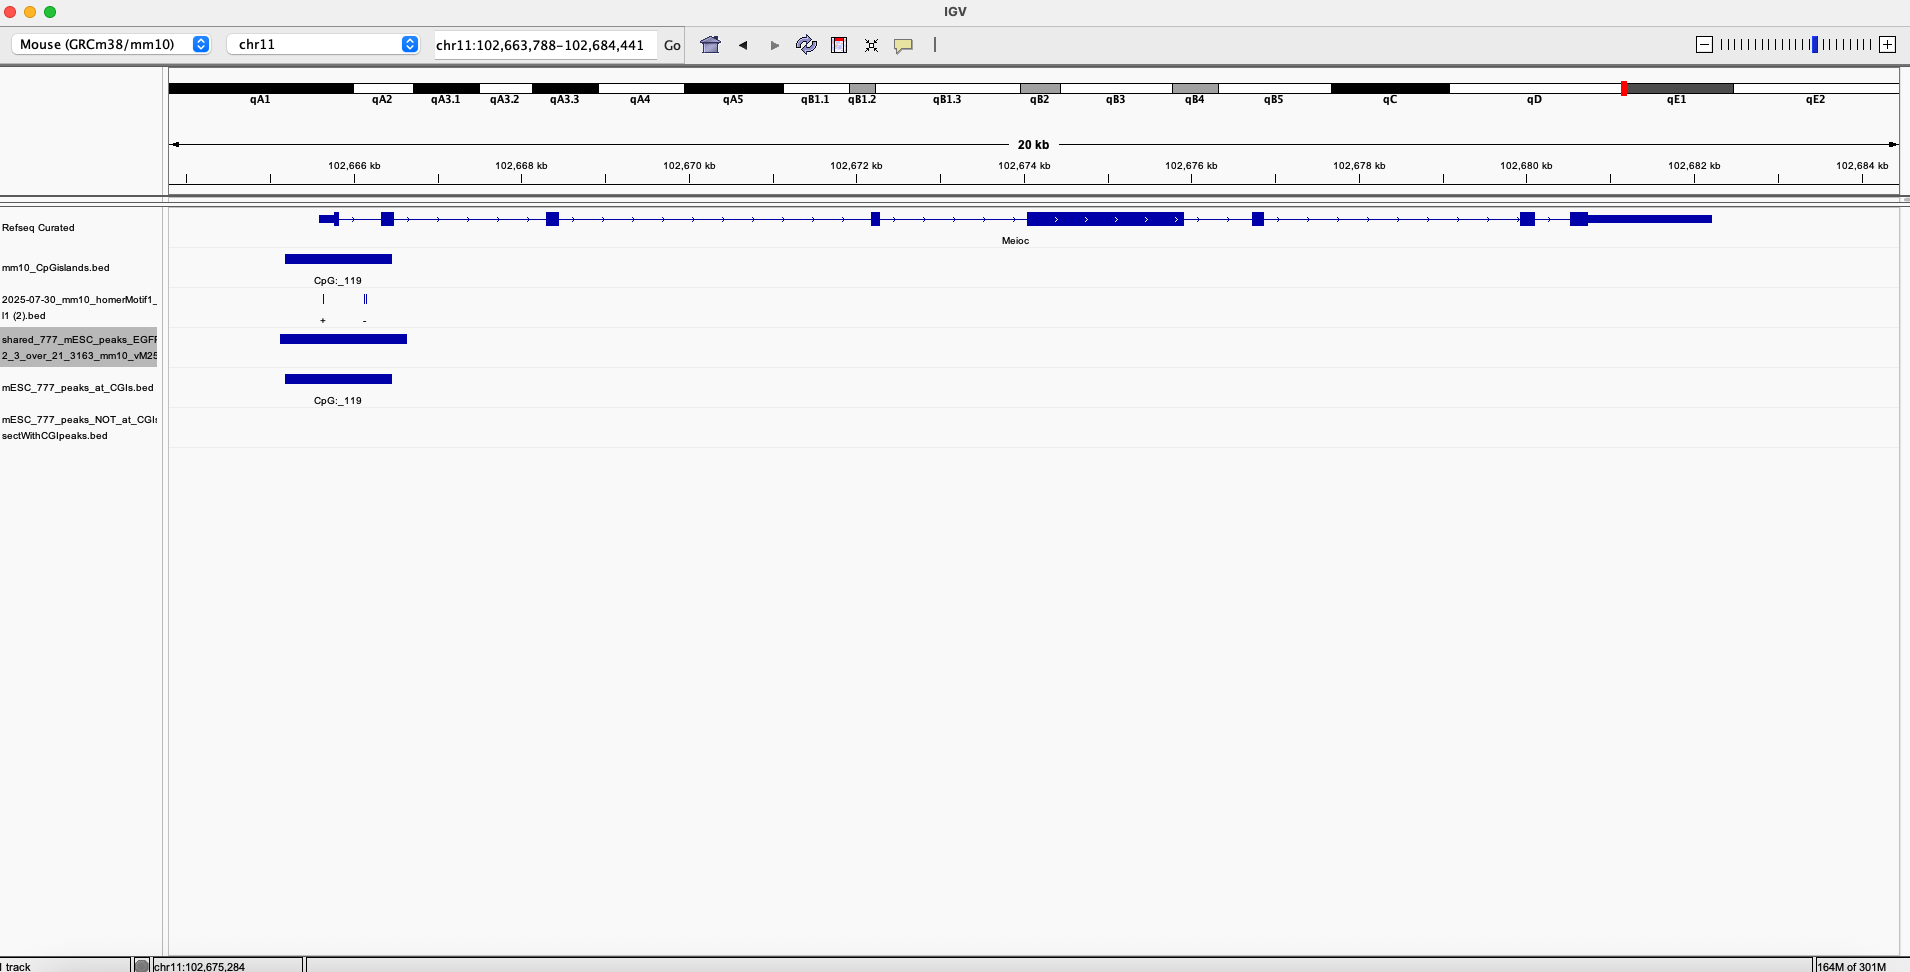

In [11]:
mkdir -p /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/png
cd /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration

module load IGV
xvfb-run --server-args="-screen 0 1920x1080x24" igv.sh -b igv_batch.txt

[-] Unloading IGV  2.17.4 
[-] Unloading java 17.0.17+10  ... 
[+] Loading IGV  2.17.4 
[+] Loading java 17.0.17+10  ... 
mem = 2g
tmpdir = /lscratch/13544272/igvtmp
INFO [Mar 10,2026 10:50] [Main] Startup  IGV Version 2.17.4 03/26/2024 12:38 PM
INFO [Mar 10,2026 10:50] [Main] Java 17.0.17 (build 17.0.17+10) 2025-10-21
INFO [Mar 10,2026 10:50] [Main] Java Vendor: Eclipse Adoptium https://adoptium.net/
INFO [Mar 10,2026 10:50] [Main] JVM: OpenJDK 64-Bit Server VM Temurin-17.0.17+10   
INFO [Mar 10,2026 10:50] [Main] OS: Linux 4.18.0-425.19.3a.el8.x86_64 amd64
INFO [Mar 10,2026 10:50] [Main] IGV Directory: /home/gallegosda/igv
SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.
INFO [Mar 10,2026 10:50] [CommandListener] Listening on port 60151
INFO [Mar 10,2026 10:50] [BatchRunner] Executing batch script: igv_batch.txt
INFO [Mar 10,

## Get intersection while keeping original CGI size

In [3]:
cd /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration

In [4]:
module load bedtools

[+] Loading bedtools  2.31.1 


In [ ]:
-u	Write the original A entry _once_ if _any_ overlaps found in B.
		- In other words, just report the fact >=1 hit was found.
		- Overlaps restricted by -f and -r.

In [5]:
bedtools intersect -a mm10_CpGislands.bed -b shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -u > CGIs_that_overlap_mESC_777_peaks_at_least_once.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369



In [7]:
# Get non-intersecting
bedtools intersect -a mm10_CpGislands.bed -b shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -v > CGIS_that_DO_NOT_overlap_mESC_777_peaks.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
chr1	4491712	4493369



In [8]:
bedtools intersect -a shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -b CGIs_that_overlap_mESC_777_peaks_at_least_once.bed -v  > Zfp777_peaks_that_DO_NOT_overlap_CGIs.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071



In [10]:
# Try to get the 777 peaks that do intersect with a CGI using the CGI overlap bed and 777 nonoverlap bed
bedtools intersect -a shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -b Zfp777_peaks_that_DO_NOT_overlap_CGIs.bed -v  > ATTEMPT0_Zfp777_peaks_that_DO_overlap_CGIs.bed

***** WARNING: File Zfp777_peaks_that_DO_NOT_overlap_CGIs.bed has inconsistent naming convention for record:
chr1	22327660	22327974

***** WARNING: File Zfp777_peaks_that_DO_NOT_overlap_CGIs.bed has inconsistent naming convention for record:
chr1	22327660	22327974



In [12]:
# Get the number of times each peak overlaps with the CGI bed track (i.e., how many CGIs does each peak intersect with?)
bedtools intersect -a shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed -b mm10_CpGislands.bed -c  > Zfp777_peaks_overlapping_CGIs_INCLUDING_NUMBER.bed

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071

***** WARNING: File shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed has inconsistent naming convention for record:
GL456211.1	44106	45071



## Get TSS Heatmap

Just writing down for myself and you to not forget what we discussed as possibly meaningful next to the statistical comparison of todsy‘s analysis: 1 where does 777 bind relative to TSS (get TSS (via gtf) from homer of mESC peaks, make unique for genes (some genes have multiple peaks) and plot 777 EGFP clone 3 with center on TSS 2. (this may or may not be trickier) where across the CGI does 777 bind in mESCs (stretch/plot CGI to same length and plot 777 bw signal over that (not sure how to do that yet)

In [13]:
module load deeptools

[+] Loading deeptools  3.5.6  on cn0016 
[+] Loading singularity  4.2.2  on cn0016 


In [29]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 20000 -a 20000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/TSS_from_distance.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping 2010315B03Rik, due to being absent in the computeMatrix output.
Skipping Fgf14, due to being absent in the computeMatrix output.


In [32]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2801_uniqueGenes_777peaks_DistanceFromTSS_+-20kb.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [33]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 5000 -a 5000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/TSS_from_distance.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping Ccr1, due to being absent in the computeMatrix output.
Skipping 2010315B03Rik, due to being absent in the computeMatrix output.
Skipping Fgf14, due to being absent in the computeMatrix output.


In [34]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2801_uniqueGenes_777peaks_DistanceFromTSS_+-5kb.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [35]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 2000 -a 2000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/TSS_from_distance.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping Ccr1, due to being absent in the computeMatrix output.
Skipping 2010315B03Rik, due to being absent in the computeMatrix output.
Skipping Fgf14, due to being absent in the computeMatrix output.


In [36]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2801_uniqueGenes_777peaks_DistanceFromTSS_+-2kb.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [39]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 1000 -a 1000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/TSS_from_distance.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping Ccr1, due to being absent in the computeMatrix output.
Skipping 2010315B03Rik, due to being absent in the computeMatrix output.
Skipping Fgf14, due to being absent in the computeMatrix output.


In [40]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2801_uniqueGenes_777peaks_DistanceFromTSS_+-1kb.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [37]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 500 -a 500 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/TSS_from_distance.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping Ccr1, due to being absent in the computeMatrix output.
Skipping 2010315B03Rik, due to being absent in the computeMatrix output.
Skipping Or5bh3, due to being absent in the computeMatrix output.
Skipping Fgf14, due to being absent in the computeMatrix output.


In [38]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2801_uniqueGenes_777peaks_DistanceFromTSS_+-0.5kb.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

# Redo computeMatrix and plotHeatmap using GTF

In [2]:
head -n 10 /data/gallegosda/GEO/RNA-seq/fastq/genome/gencode.vM23.primary_assembly.annotation.gtf

##description: evidence-based annotation of the mouse genome (GRCm38), version M23 (Ensembl 98)
##provider: GENCODE
##contact: gencode-help@ebi.ac.uk
##format: gtf
##date: 2019-09-06
chr1	HAVANA	gene	3073253	3074322	.	+	.	gene_id "ENSMUSG00000102693.1"; gene_type "TEC"; gene_name "4933401J01Rik"; level 2; mgi_id "MGI:1918292"; havana_gene "OTTMUSG00000049935.1";
chr1	HAVANA	transcript	3073253	3074322	.	+	.	gene_id "ENSMUSG00000102693.1"; transcript_id "ENSMUST00000193812.1"; gene_type "TEC"; gene_name "4933401J01Rik"; transcript_type "TEC"; transcript_name "4933401J01Rik-201"; level 2; transcript_support_level "NA"; mgi_id "MGI:1918292"; tag "basic"; havana_gene "OTTMUSG00000049935.1"; havana_transcript "OTTMUST00000127109.1";
chr1	HAVANA	exon	3073253	3074322	.	+	.	gene_id "ENSMUSG00000102693.1"; transcript_id "ENSMUST00000193812.1"; gene_type "TEC"; gene_name "4933401J01Rik"; transcript_type "TEC"; transcript_name "4933401J01Rik-201"; exon_number 1; exon_id "ENSMUSE00001343744.1"; lev

In [3]:
cd /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration
wget https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M23/gencode.vM23.basic.annotation.gtf.gz

--2026-03-11 10:40:29--  https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M23/gencode.vM23.basic.annotation.gtf.gz
Resolving dtn21-e0 (dtn21-e0)... 10.1.200.75
Connecting to dtn21-e0 (dtn21-e0)|10.1.200.75|:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 19771189 (19M) [application/x-gzip]
Saving to: ‘gencode.vM23.basic.annotation.gtf.gz’

gencode.vM23.basic. 100%[===================>]  18.85M  21.7MB/s    in 0.9s    

2026-03-11 10:40:30 (21.7 MB/s) - ‘gencode.vM23.basic.annotation.gtf.gz’ saved [19771189/19771189]



In [4]:
gunzip gencode*

## Get TSS Heatmap

Just writing down for myself and you to not forget what we discussed as possibly meaningful next to the statistical comparison of todsy‘s analysis: 1 where does 777 bind relative to TSS (get TSS (via gtf) from homer of mESC peaks, make unique for genes (some genes have multiple peaks) and plot 777 EGFP clone 3 with center on TSS 2. (this may or may not be trickier) where across the CGI does 777 bind in mESCs (stretch/plot CGI to same length and plot 777 bw signal over that (not sure how to do that yet)

In [5]:
module load deeptools

[+] Loading deeptools  3.5.6  on cn0039 
[+] Loading singularity  4.2.2  on cn0039 


#### Baseline plot: bw over 3163 peaks

In [13]:
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/shared_777_mESC_peaks_EGFP_clone2_3_over_21_3163_mm10_vM25.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [14]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out 'baseline.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [18]:
# baseline over 2672 peaks

In [19]:
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping -_r67, due to being absent in the computeMatrix output.
Skipping +_r718, due to being absent in the computeMatrix output.
Skipping -_r968, due to being absent in the computeMatrix output.


In [20]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out 'baseline_2672.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

### TSS plots

**Reference-Point**

In [ ]:
# 500bp

In [65]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 500 -a 500 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

Skipping Krtap21-1, due to being absent in the computeMatrix output.
Skipping Gm20901, due to being absent in the computeMatrix output.


In [66]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_+-0.5kb_reference_point.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [67]:
# 1kb

In [68]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 1000 -a 1000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [69]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_+-1kb_reference_point.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [70]:
# 2kb

In [71]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 2000 -a 2000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [72]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_+-2kb_reference_point.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [73]:
# 5kb

In [74]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 5000 -a 5000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [75]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_+-5kb_reference_point.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

In [76]:
# 10kb

In [77]:
computeMatrix reference-point \
    --referencePoint TSS \
    -b 10000 -a 10000 \
    -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
    -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
    --skipZeros \
    -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
    --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [78]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_+-10kb_reference_point.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no

**Scale-Regions**

In [79]:
# 500bp

In [80]:
computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 500 -a 500 \
  --regionBodyLength 1000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix2_multipleBW_l2r_twoGroups_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [81]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_+-0.5kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6

In [97]:
# 1kb

In [98]:
computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 1000 -a 1000 \
  --regionBodyLength 2000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix2_multipleBW_l2r_twoGroups_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [99]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_+-1kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6

In [100]:
# 2kb

In [101]:
computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 2000 -a 2000 \
  --regionBodyLength 4000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix2_multipleBW_l2r_twoGroups_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

In [102]:
plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_+-2kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6

In [103]:
# 5kb

computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 5000 -a 5000 \
  --regionBodyLength 1000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix2_multipleBW_l2r_twoGroups_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_+-5kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6

In [104]:
# 5kb

computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 5000 -a 5000 \
  --regionBodyLength 1000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix2_multipleBW_l2r_twoGroups_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_+-5kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6

In [105]:
# 10kb

computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/bed_2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_noHeader.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 10000 -a 10000 \
  --regionBodyLength 1000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix2_multipleBW_l2r_twoGroups_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/regions1_777peaks_TSS.bed

plotHeatmap -m matrix1_777peaks_TSS.gz \
     -out '2672_unique_genes_with_Zfp777_peak_gencode_vM23_mm10_TSS_TES_+-10kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6

# CGI heatmaps

In [5]:
module load deeptools
cd /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration

[-] Unloading deeptools  3.5.6 on cn0012 
[+] Loading deeptools  3.5.6  on cn0012 
[-] Unloading singularity  4.2.2  on cn0012 
[+] Loading singularity  4.2.2  on cn0012 


In [6]:
# 2kb

In [11]:
computeMatrix scale-regions \
  -R /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/CGIs_that_overlap_mESC_777_peaks_at_least_once.bed \
  -S /data/gallegosda/GEO/ChIP-seq/fastq/align_these/aligned/bw/mm10_bw/mESC_R1_777_EGFP_floxed_clone_3_GFP_SeqDepthNorm.bw  \
  -b 2000 -a 2000 \
  --regionBodyLength 2000 \
  --skipZeros -o /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_CGIs_with_777peaks_TSS.gz \
  --outFileNameMatrix /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/matrix1_scaled.tab \
  --outFileSortedRegions /data/gallegosda/GEO/Figures/3-9-26_CGI_Data_Exploration/region1_CGIs_with_777peaks_TSS.bed

In [14]:
plotHeatmap -m matrix1_CGIs_with_777peaks_TSS.gz \
     -out '2519_unique_CGIs_that_overlap_>=1_Zfp777_peak_CGIstart_CGIend_+-2kb_scale_regions.png' \
     --colorMap Reds \
     --boxAroundHeatmaps no \
     --heatmapHeight 28 \
     --heatmapWidth 6 \
     --startLabel 'CGI Start' \
     --endLabel 'CGI End' \
     --regionsLabel 'CGIs at 1+ Zfp777 Peak'